Code pour acceder et lire SQL :

In [ ]:
%pip install nbformat


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
%pip install plotly.express


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
%pip install seaborn
%pip install scikit-learn


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
%pip install pandas mysql-connector-python sqlalchemy


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import mysql.connector
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Connexion
bdd = mysql.connector.connect(
    host="localhost",
    port=8889,
    user="root",
    password="root",
    database="agriculture"
)

# Chargement manuel de chaque table
adapter = pd.read_sql_query("SELECT * FROM adapter", bdd)
contrainte = pd.read_sql_query("SELECT * FROM contrainte_temperature", bdd)
culture = pd.read_sql_query("SELECT * FROM culture", bdd)
releve = pd.read_sql_query("SELECT * FROM releve_meteo", bdd)
saison = pd.read_sql_query("SELECT * FROM saisonnalite", bdd)
station = pd.read_sql_query("SELECT * FROM station_meteo", bdd)
sol = pd.read_sql_query("SELECT * FROM type_sol", bdd)
villes = pd.read_sql_query("SELECT * FROM villes", bdd)

# Fermeture de la connexion
bdd.close()

# Vérification
print(releve.head())

/var/folders/2k/hg13125105zgd1df9g7bkmn40000gn/T/ipykernel_26029/1992561011.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  adapter = pd.read_sql_query("SELECT * FROM adapter", bdd)
/var/folders/2k/hg13125105zgd1df9g7bkmn40000gn/T/ipykernel_26029/1992561011.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  contrainte = pd.read_sql_query("SELECT * FROM contrainte_temperature", bdd)
/var/folders/2k/hg13125105zgd1df9g7bkmn40000gn/T/ipykernel_26029/1992561011.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  culture 

   releve_id        date  heure  temperature  point_de_rose  humidite  \
0          1  2022-01-01 0 days       284.45         283.35      93.0   
1          2  2022-01-01 0 days       278.85         278.45      97.0   
2          3  2022-01-01 0 days       280.05         279.95      99.0   
3          4  2022-01-01 0 days       282.25         282.25     100.0   
4          5  2022-01-01 0 days       284.25         281.25      82.0   

   temperature_min_sol_12h  precipitations_dernieres_24h  station_id  
0                   282.05                          -0.1           1  
1                   278.75                           0.0         195  
2                   281.85                           0.4         183  
3                   283.55                           0.4         183  
4                   284.05                           0.2         183  


/var/folders/2k/hg13125105zgd1df9g7bkmn40000gn/T/ipykernel_26029/1992561011.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  saison = pd.read_sql_query("SELECT * FROM saisonnalite", bdd)
/var/folders/2k/hg13125105zgd1df9g7bkmn40000gn/T/ipykernel_26029/1992561011.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  station = pd.read_sql_query("SELECT * FROM station_meteo", bdd)
/var/folders/2k/hg13125105zgd1df9g7bkmn40000gn/T/ipykernel_26029/1992561011.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sol = pd.read_sq

Graphique Méteo-années (M)

Temperature par rapport aux autres variables (I)

Moyenne sur 4 années :
288.6707155702887


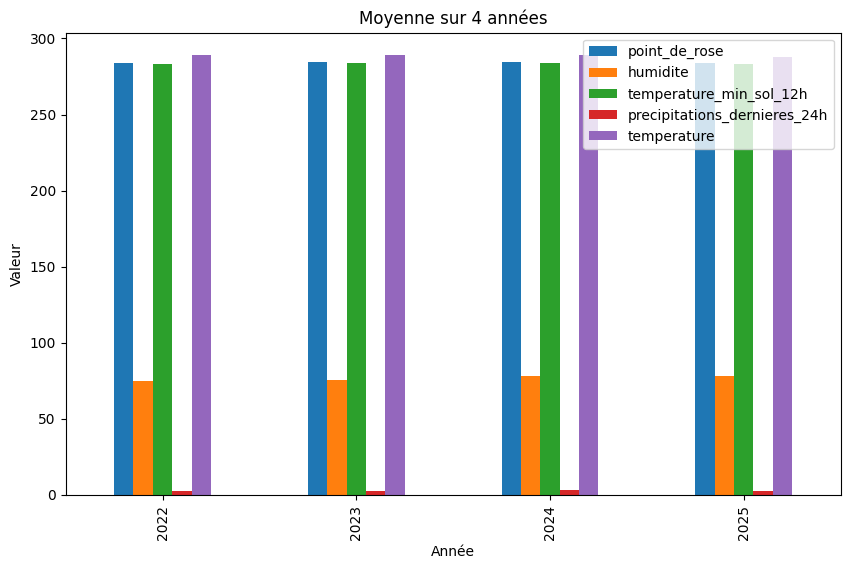

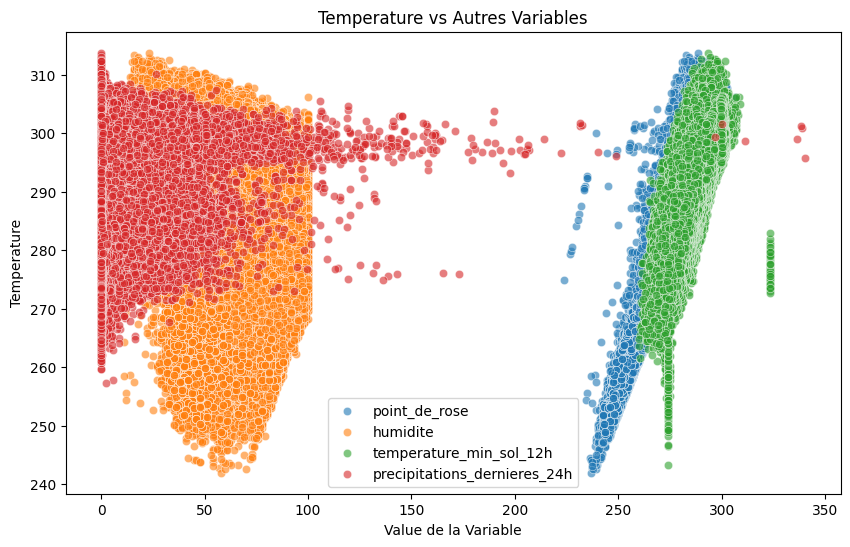

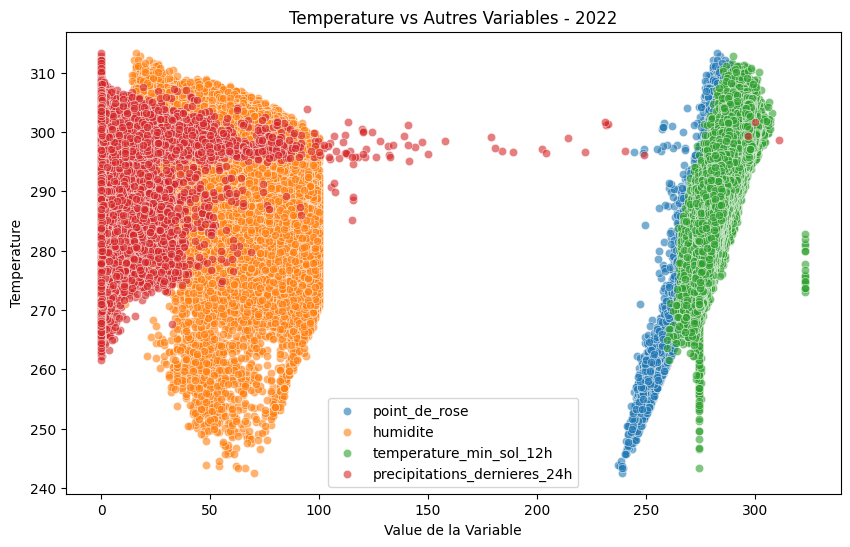

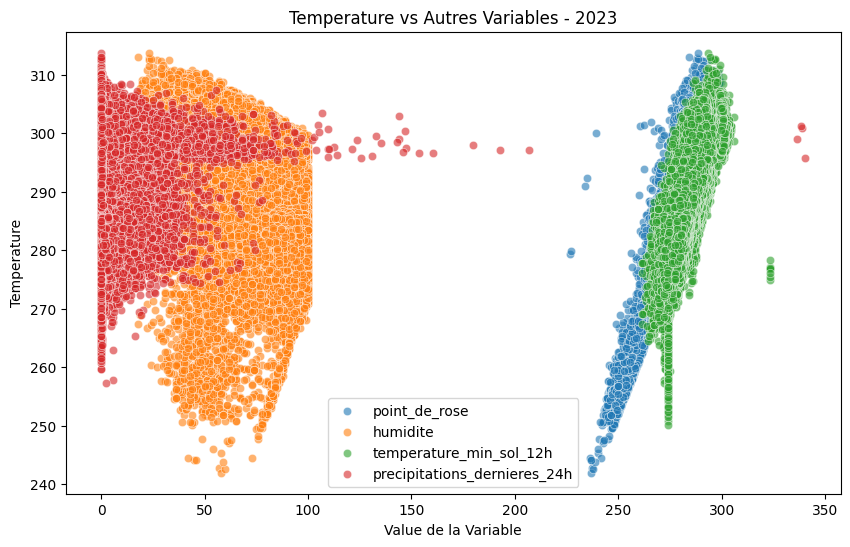

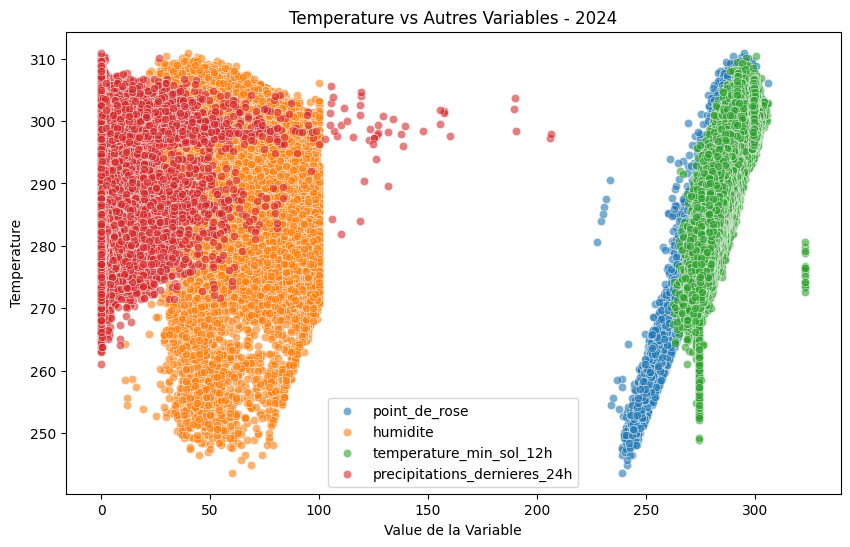

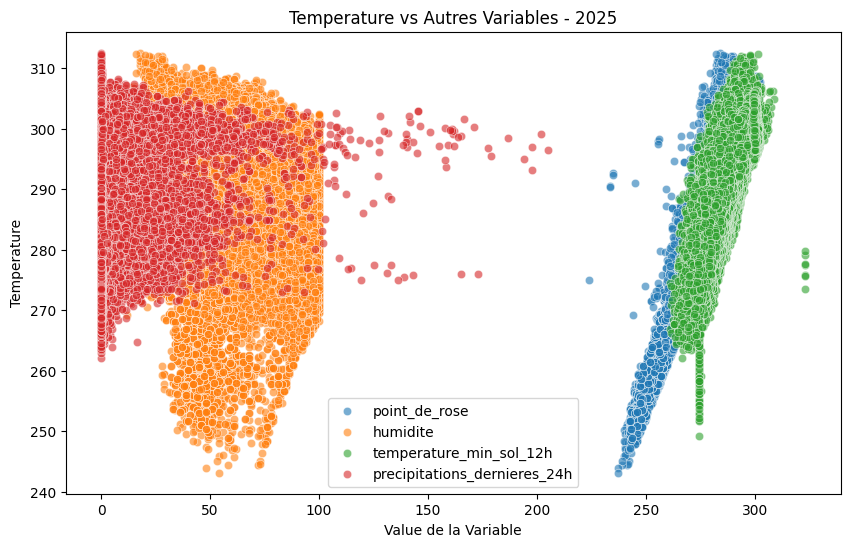

In [ ]:
# On ne garde que l'année de la date
releve['date'] = pd.to_datetime(releve['date'])
releve['année'] = releve['date'].dt.year

variables = [
    'point_de_rose',
    'humidite',
    'temperature_min_sol_12h',
    'precipitations_dernieres_24h' ]


# Affichage de la moyenne des variables sur les 4 années

moy_an = releve.groupby('année')[variables + ['temperature']].mean()
moy_temp = releve['temperature'].mean()

print("Moyenne de la température sur quatre années :")
print(moy_temp)

moy_an.plot(kind='bar', figsize=(10,6))
plt.title("Moyennes sur quatre années")
plt.xlabel("Année")
plt.ylabel("Valeur")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()



# Affichage de la temperature par rapport aux autres variables sur les 4 années

plt.figure(figsize=(10,6))

for var in (variables):
      sns.scatterplot(
          data=releve,
          x=var,
          y='temperature',
          alpha=0.6,
          label=var
        )

plt.title(f"Température par rapport aux autres variables")
plt.xlabel("Valeur de la variable")
plt.ylabel("Température")
plt.legend()
plt.show()



# Affichage de la temperature par rapport aux autres variables pour chaque année

années = sorted(releve['année'].unique())

for année in années:
    releve_annees = releve[releve['année'] == année]

    plt.figure(figsize=(10,6))

    for var in (variables):
        sns.scatterplot(
            data=releve_annees,
            x=var,
            y='temperature',
            alpha=0.6,
            label=var
        )

    plt.title(f"Température par rapport aux autres variables - {année}")
    plt.xlabel("Valeur de la variable")
    plt.ylabel("Température")
    plt.legend()
    plt.show()

Carte station météo avec temperature (S)

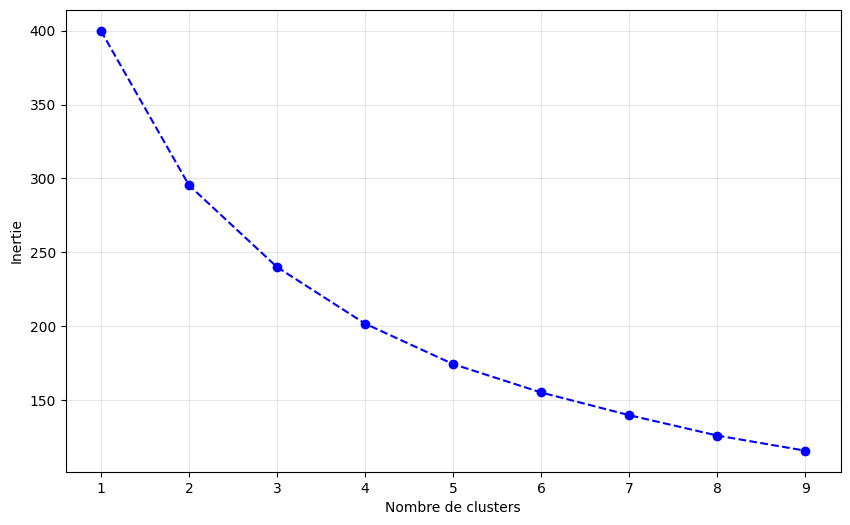

    id_culture     nom_culture  cluster
99         100          Litchi        0
72          73         Abricot        0
67          68   Pois gourmand        0
66          67          Cardon        0
25          26    Haricot vert        0
..         ...             ...      ...
52          53  Chou romanesco        3
76          77          Cerise        3
75          76           Prune        3
7            8       Aubergine        3
27          28            Fève        3

[100 rows x 3 columns]


,Nombre_de_clusters,Inertie
0,1,400.000000
1,2,295.343969
2,3,239.889904
3,4,201.557289
4,5,174.145493
5,6,154.912665
6,7,139.536079
7,8,125.740811
8,9,115.468398


Clustering fruits/legumes selon type de sol (M)

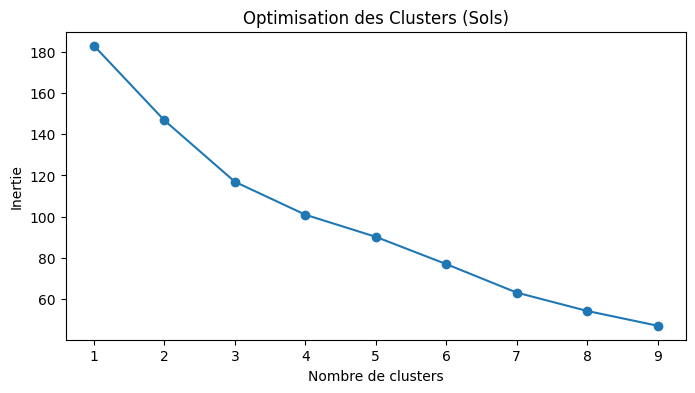

Fichier CSV créé : clusters_sol.csv


/var/folders/2k/hg13125105zgd1df9g7bkmn40000gn/T/ipykernel_26029/3321514571.py:85: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




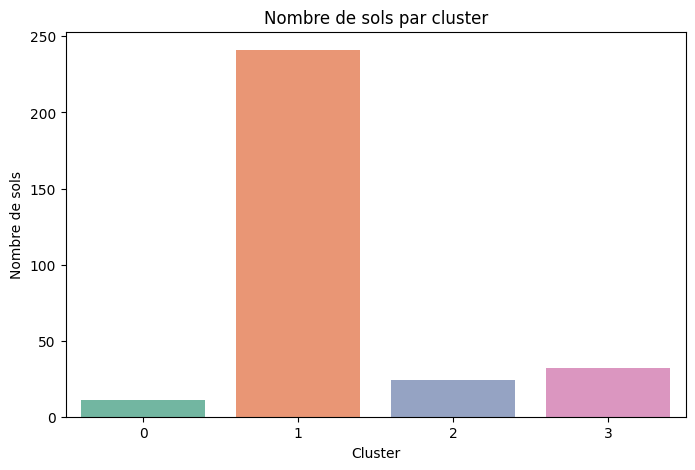


=== Cluster 0 ===
      soil_name nom_culture
0  Sol argileux         NaN
1  Sol calcaire       Pomme
2  Sol calcaire       Poire
3  Sol calcaire     Abricot
4  Sol calcaire       Pêche

=== Cluster 1 ===
       soil_name     nom_culture
11   Sol marneux             NaN
12  Sol limoneux          Tomate
13  Sol limoneux  Pomme de terre
14  Sol limoneux          Oignon
15  Sol limoneux             Ail

=== Cluster 2 ===
        soil_name nom_culture
252  Sol humifère  Chou rouge
253  Sol humifère   Chou vert
254  Sol humifère     Épinard
255  Sol humifère      Laitue
256  Sol humifère       Mâche

=== Cluster 3 ===
       soil_name  nom_culture
276  Sol sableux      Carotte
277  Sol sableux        Radis
278  Sol sableux        Navet
279  Sol sableux    Betterave
280  Sol sableux  Topinambour


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans

# 1. UTILISATION DES DONNÉES SQL (Variables déjà en mémoire)
# On utilise 'sol' (ta table type_sol), 'culture' et 'adapter'
df_sol = sol.copy()

# 2. PRÉPARATION DES COLONNES
num_cols = ["sand_pct", "silt_pct", "clay_pct", "pH",
            "organic_matter_pct", "water_holding_capacity"]

cat_cols = ["drainage", "irrigation_frequency",
            "soil_name", "texture_class"]

# Transformation des caractères en valeurs binaires (OneHotEncoder)
encoder = OneHotEncoder(sparse_output=False)
encoded_cat = encoder.fit_transform(df_sol[cat_cols])

encoded_cat_df = pd.DataFrame(
    encoded_cat,
    columns=encoder.get_feature_names_out(cat_cols)
)

# Normalisation des valeurs numériques
scaler = StandardScaler()
scaled_num = scaler.fit_transform(df_sol[num_cols])
scaled_num_df = pd.DataFrame(scaled_num, columns=num_cols)

# Fusion pour créer la matrice X
X = pd.concat([scaled_num_df, encoded_cat_df], axis=1)

# 3. ANALYSE DU NOMBRE DE CLUSTERS (Elbow Method)
inertia = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.title("Optimisation des Clusters (Sols)")
plt.show()

# 4. K-MEANS ET CLUSTERING
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_sol["cluster"] = kmeans.fit_predict(X)

# Création du tableau des sols clusterisés
soil_clusters = df_sol[["soil_id", "soil_name", "cluster"]].sort_values("cluster")

# 5. FUSION FINALE (Sols + Adaptations + Cultures)
# On lie tes tables SQL : soil_clusters -> adapter -> culture
sols_adapte = soil_clusters.merge(adapter, on="soil_id", how="left")
fusion_finale = sols_adapte.merge(culture, on="id_culture", how="left")

# Enregistrement
fusion_finale.to_csv("clusters_sol.csv", index=False)
print("Fichier CSV créé : clusters_sol.csv")

# 6. VISUALISATIONS JOLIES
# Graphique interactif Plotly
fig = px.scatter(
    fusion_finale,
    x='id_culture',
    y='soil_id',
    color='cluster',
    # Correction ici : 'type_culture' au lieu de 'type'
    hover_data=['soil_name', 'nom_culture', 'type_culture'],
    title="Répartition des sols par cluster (Interactif)",
    labels={'id_culture':'ID Culture', 'soil_id':'ID Sol'}
)
fig.show()

# Barplot Seaborn
plt.figure(figsize=(8,5))
cluster_counts = fusion_finale['cluster'].value_counts().sort_index()
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="Set2")
plt.xlabel("Cluster")
plt.ylabel("Nombre de sols")
plt.title("Nombre de sols par cluster")
plt.show()

# Affichage par groupe
for cluster_id in sorted(fusion_finale['cluster'].unique()):
    print(f"\n=== Cluster {cluster_id} ===")
    print(fusion_finale[fusion_finale['cluster'] == cluster_id][['soil_name', 'nom_culture']].head())

Clustering fruits/legumes selon type Temperature (M)

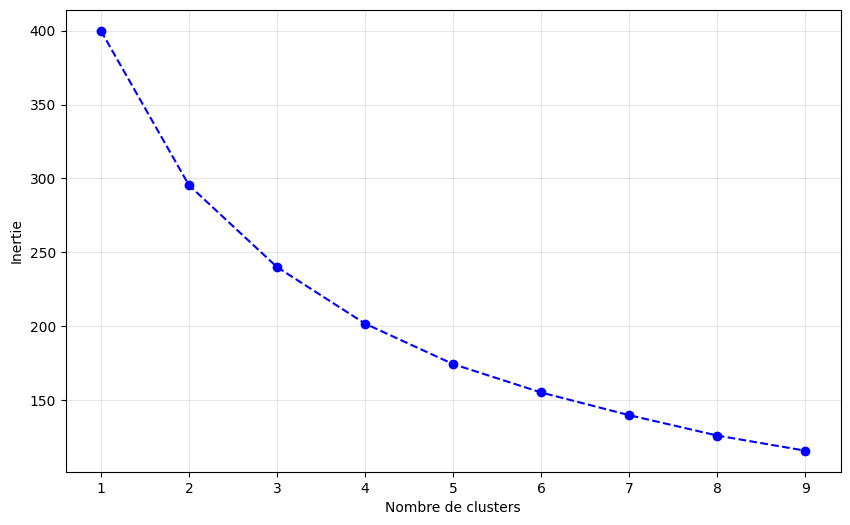

    id_culture     nom_culture  cluster
99         100          Litchi        0
72          73         Abricot        0
67          68   Pois gourmand        0
66          67          Cardon        0
25          26    Haricot vert        0
..         ...             ...      ...
52          53  Chou romanesco        3
76          77          Cerise        3
75          76           Prune        3
7            8       Aubergine        3
27          28            Fève        3

[100 rows x 3 columns]


,Nombre_de_clusters,Inertie
0,1,400.000000
1,2,295.343969
2,3,239.889904
3,4,201.557289
4,5,174.145493
5,6,154.912665
6,7,139.536079
7,8,125.740811
8,9,115.468398


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt

# 1. FUSION DES DONNÉES (SQL)
df_fusion = pd.merge(culture, contrainte, on="id_culture", how="inner")
df_fusion.columns = df_fusion.columns.str.strip()

# 2. PRÉPARATION
num_cols = ["t_min_germination", "t_opt_germination", "t_ideale_croissance", "t_min_croissance"]
df_clustering = df_fusion[num_cols].fillna(0) # Pour avoir les mêmes chiffres qu'elle

# Normalisation
scaler = StandardScaler()
X = scaler.fit_transform(df_clustering)

# 3. CALCUL DE L'INERTIE ET GRAPHIQUE
inertia = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

# --- AFFICHAGE DU GRAPHIQUE ---
plt.figure(figsize=(10, 6))
plt.plot(range(1, 10), inertia, marker='o', linestyle='--', color='b')
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.grid(True, alpha=0.3)
plt.show()

# 4. EXÉCUTION FINALE (K=4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_fusion["cluster"] = kmeans.fit_predict(X)

# 5. RÉSULTATS
clusters_final = df_fusion[["id_culture", "nom_culture", "cluster"]].sort_values("cluster")
print(clusters_final)

# Enregistrement CSV
clusters_final.to_csv("clusters_Temperature.csv", index=False)

# Affichage du tableau d'inertie
results = pd.DataFrame({
    "Nombre_de_clusters": range(1, 10),
    "Inertie": inertia
})
results

Clustering fruits/legumes selon type de sol et Temperature (M)

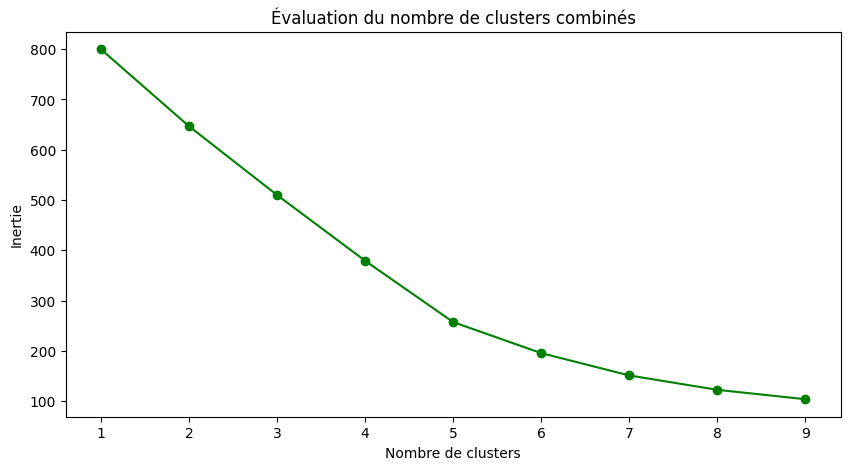


--- Synthèse finale des cultures ---
   id_culture     nom_culture  cluster_final
0         1.0          Tomate              4
1         2.0         Carotte              3
2         3.0  Pomme de terre              0
3         4.0          Oignon              4
4         5.0             Ail              1

Fichier 'synthese_cultures_finale.csv' créé avec succès.


,Nb_Clusters,Inertie
0,1,800.000000
1,2,646.869804
2,3,509.986834
3,4,379.240651
4,5,257.237357
5,6,195.526815
6,7,151.110013
7,8,122.505665
8,9,103.822105


In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer, StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. LECTURE DES RÉSULTATS PRÉCÉDENTS
df_culture = pd.read_csv("clusters_Temperature.csv")
df_soil = pd.read_csv("clusters_sol.csv")

# 2. FUSION DES DEUX ANALYSES
# On lie les sols et les cultures pour voir quelle plante appartient à quel groupe de température ET de sol
df = pd.merge(df_soil, df_culture, on=["id_culture", "nom_culture"], how="left")

# 3. AGRÉGATION PAR CULTURE
# On veut un profil unique par plante
df_agg = df.groupby(['id_culture', 'nom_culture']).agg({
    'cluster_y': 'first',           # On garde le cluster de température (nommé y ici)
    'cluster_x': lambda x: list(x)  # On liste tous les clusters de sols compatibles
}).reset_index()

# 4. ENCODAGE POUR LE K-MEANS FINAL
# On transforme les clusters de culture en colonnes binaires
cluster_y_encoded = pd.get_dummies(df_agg['cluster_y'], prefix='temp_cluster')

# On transforme la liste des clusters de sols avec MultiLabelBinarizer
mlb = MultiLabelBinarizer()
cluster_x_encoded = pd.DataFrame(mlb.fit_transform(df_agg['cluster_x']),
                                 columns=[f"soil_cluster_{c}" for c in mlb.classes_])

# Concaténation des deux types de clusters
X = pd.concat([cluster_y_encoded, cluster_x_encoded], axis=1)

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. ANALYSE DU COUDE (ELBOW METHOD)
inertia = []
for k in range(1, min(10, len(df_agg))):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(inertia) + 1), inertia, marker='o', color='green')
plt.title("Évaluation du nombre de clusters combinés")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.show()

# 6. CLUSTERING FINAL (On choisit 5 groupes de cultures)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_agg['cluster_final'] = kmeans.fit_predict(X_scaled)

# 7. SAUVEGARDE ET AFFICHAGE
print("\n--- Synthèse finale des cultures ---")
print(df_agg[['id_culture', 'nom_culture', 'cluster_final']].head())

df_agg.to_csv("synthese_cultures_finale.csv", index=False)
print("\nFichier 'synthese_cultures_finale.csv' créé avec succès.")

# Tableau des résultats d'inertie
results = pd.DataFrame({
    "Nb_Clusters": range(1, len(inertia) + 1),
    "Inertie": inertia
})
results

Planning de plantation (Diagramme de Gantt) (F)<br>
À partir de :
mois_semis
mois_recolte
nom_culture
saison <br>
Utilité :
Visualiser quand planter chaque culture
Comparer les cycles agricoles
Construire votre calendrier prédictif<br>
Exemple :
Tomate → semis : mars, récolte : juillet
Blé → semis : octobre, récolte : juin <br>
Structure :
Axe X : mois (janvier → décembre)
Axe Y : cultures (nom_culture)
Barres : durée entre semis et récolte

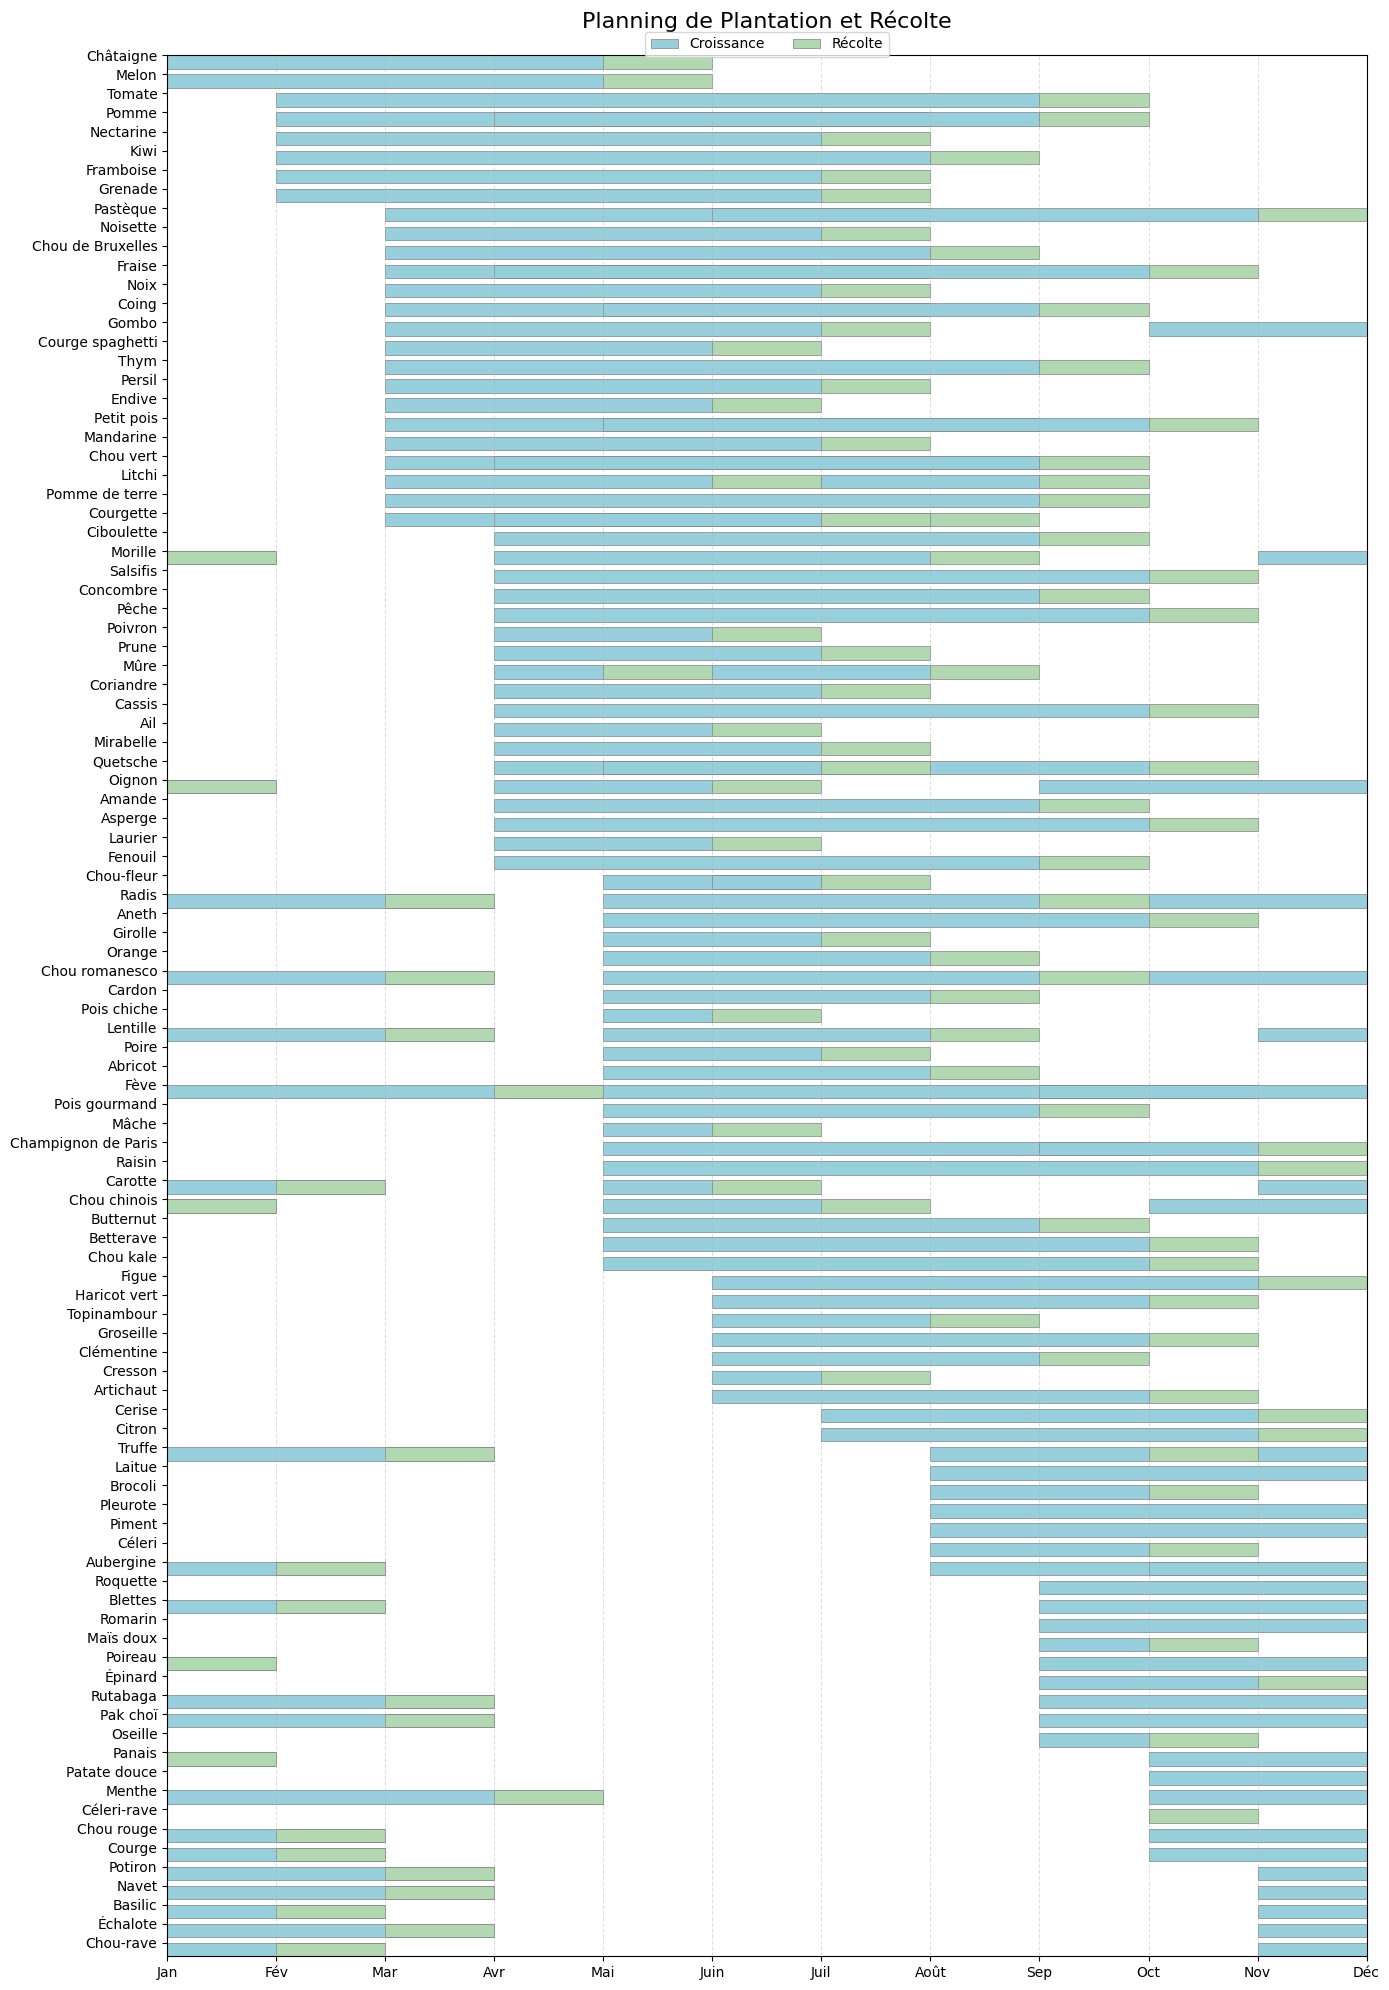

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.merge(culture, saison, on="id_culture")
df = df.sort_values(by="mois_semis", ascending=True)

fig, ax = plt.subplots(figsize=(14, 20))

for i, row in df.iterrows():
    nom = row['nom_culture']
    debut = row['mois_semis']
    fin = row['mois_recolte']

    c_pousse = "#97d0dc"
    c_recolte = '#b2d8b2'

    if debut <= fin:

        ax.barh(nom, min(fin - debut, 12 - debut + 1), left=debut,
                color=c_pousse, height=0.7, edgecolor='gray', linewidth=0.5, align='edge')

        if fin <= 12:
            ax.barh(nom, 1, left=fin, color=c_recolte, height=0.7, edgecolor='gray', linewidth=0.5, align='edge')

    else:

        ax.barh(nom, 12 - debut + 1, left=debut,
                color=c_pousse, height=0.7, edgecolor='gray', linewidth=0.5, align='edge')

        if fin >= 1:
            ax.barh(nom, min(fin, 12), left=1,
                    color=c_pousse, height=0.7, edgecolor='gray', linewidth=0.5, align='edge')

        if fin <= 12:
            ax.barh(nom, 1, left=fin, color=c_recolte, height=0.7, edgecolor='gray', linewidth=0.5, align='edge')


ax.set_title("Planning de Plantation et Récolte", fontsize=16, pad=20)
ax.invert_yaxis()
ax.set_xlim(1, 12)
ax.margins(y=0)

mois_noms = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin',
             'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc']
ax.set_xticks(range(1, 13))
ax.set_xticklabels(mois_noms)

ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.legend(['Croissance', 'Récolte'], loc='upper center', bbox_to_anchor=(0.5, 1.016), ncol=2)

plt.tight_layout()
plt.show()

Boxplot (variabilité climatique par saison)(F) <br>
saison
temperature
humidite
precipitations_dernieres_24h<br>
Utilité :
Voir si une saison est stable ou risquée pour planter
Identifier les saisons les plus fiables

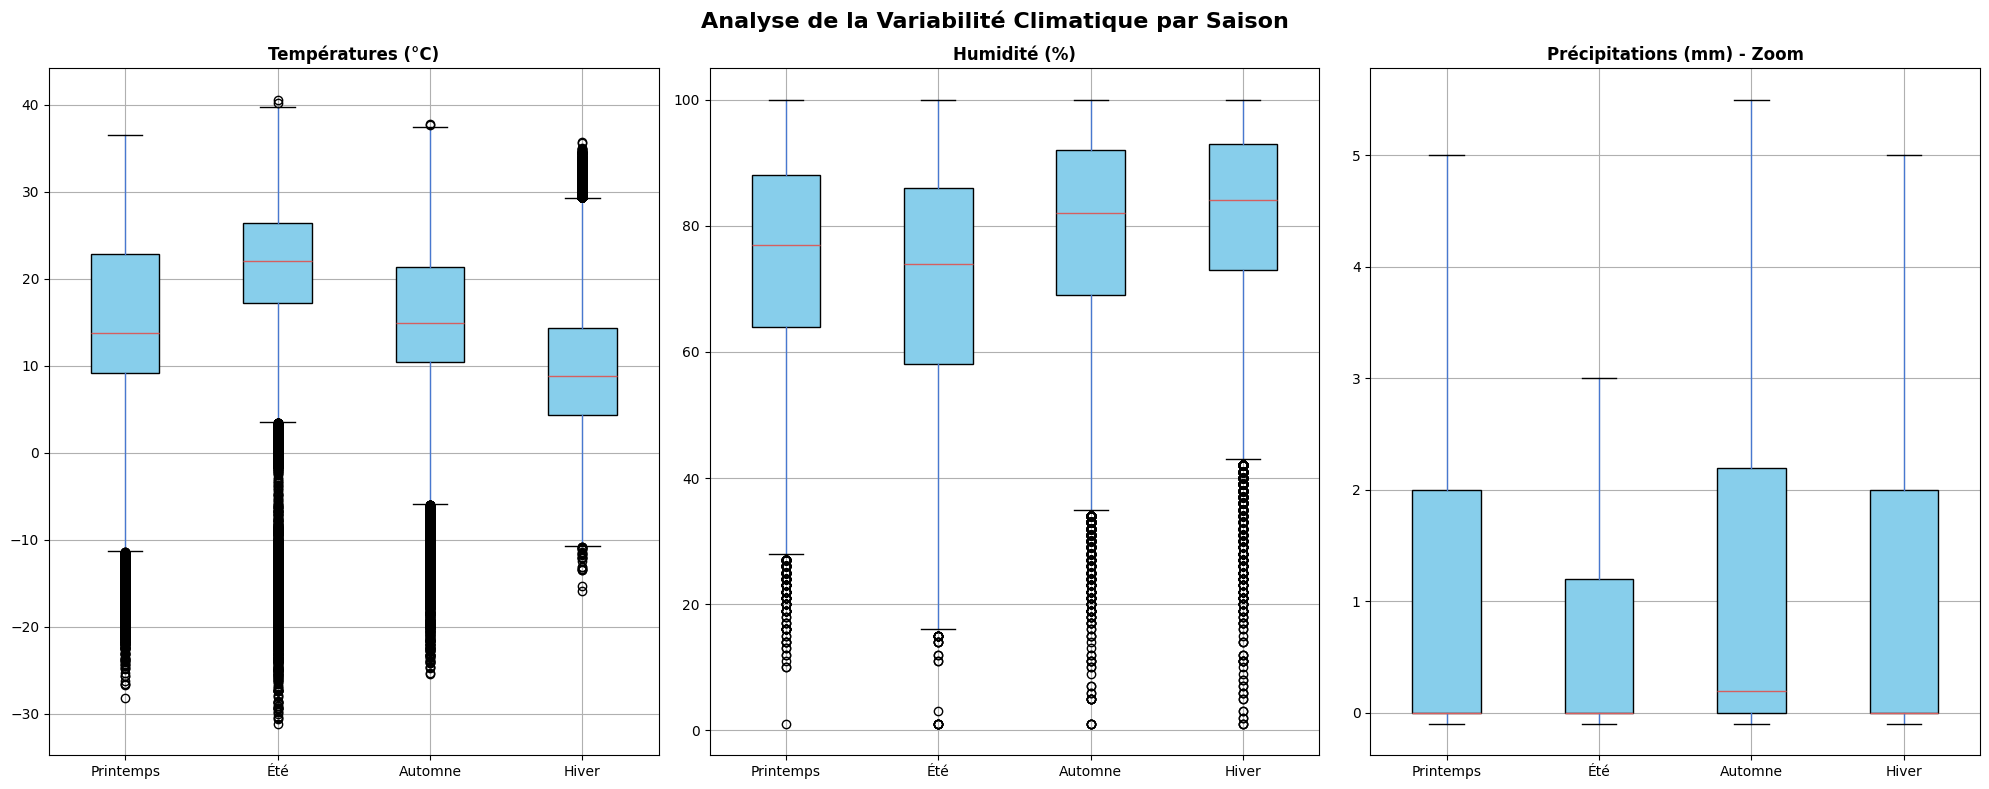

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_meteo = releve.copy()
df_meteo['date'] = pd.to_datetime(df_meteo['date'])
df_meteo['temperature'] = df_meteo['temperature'] - 273.15

def get_saison(d):
    m = d.month
    if m in [12, 1, 2]: return 'Hiver'
    if m in [3, 4, 5]:  return 'Printemps'
    if m in [6, 7, 8]:  return 'Été'
    return 'Automne'

df_meteo['saison'] = df_meteo['date'].apply(get_saison)

ordre = ['Printemps', 'Été', 'Automne', 'Hiver']
df_meteo['saison'] = pd.Categorical(df_meteo['saison'], categories=ordre, ordered=True)



plt.figure(figsize=(20, 8))

# Graphique 1 : Température
plt.subplot(1, 3, 1)
df_meteo.boxplot(column='temperature', by='saison', ax=plt.gca(), patch_artist=True,
                 boxprops=dict(facecolor='skyblue'))
plt.title('Températures (°C)', fontweight='bold')
plt.xlabel('')

plt.subplot(1, 3, 2)
df_meteo.boxplot(column='humidite', by='saison', ax=plt.gca(), patch_artist=True,
                 boxprops=dict(facecolor='skyblue'))
plt.title('Humidité (%)', fontweight='bold')
plt.xlabel('')

plt.subplot(1, 3, 3)
df_meteo.boxplot(column='precipitations_dernieres_24h', by='saison', ax=plt.gca(),
                 patch_artist=True, showfliers=False, # Le zoom est ici
                 boxprops=dict(facecolor='skyblue'))
plt.title('Précipitations (mm) - Zoom', fontweight='bold')
plt.xlabel('')

plt.suptitle('Analyse de la Variabilité Climatique par Saison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

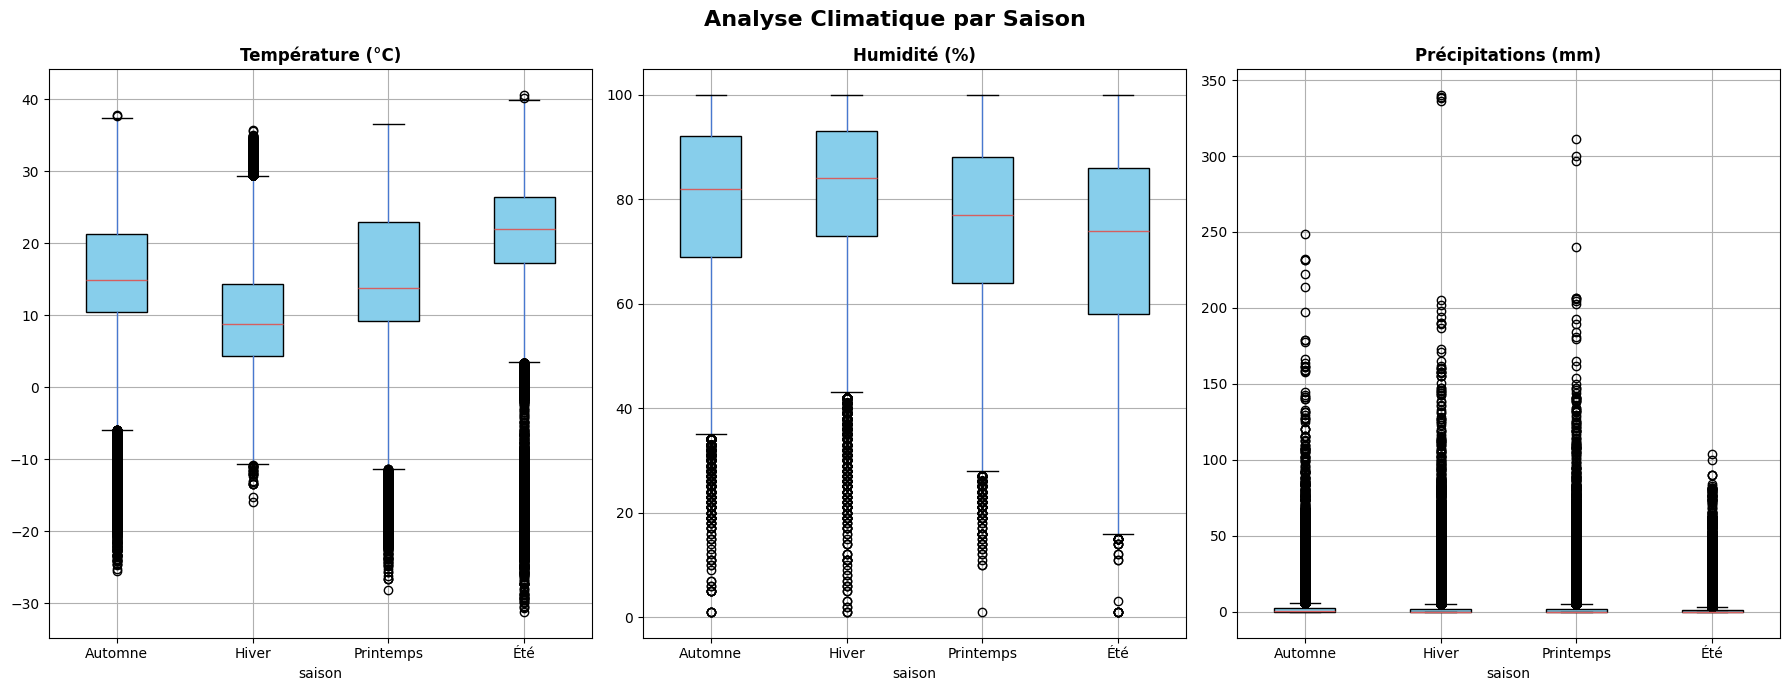

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_meteo = releve.copy()
df_meteo['date'] = pd.to_datetime(df_meteo['date'])
df_meteo['temperature'] = df_meteo['temperature'] - 273.15

def get_saison(d):
    m = d.month
    if m in [12, 1, 2]: return 'Hiver'
    if m in [3, 4, 5]:  return 'Printemps'
    if m in [6, 7, 8]:  return 'Été'
    return 'Automne'

df_meteo['saison'] = df_meteo['date'].apply(get_saison)


plt.figure(figsize=(18, 7))

plt.subplot(1, 3, 1)
df_meteo.boxplot(column='temperature', by='saison', ax=plt.gca(), patch_artist=True,
                 boxprops=dict(facecolor='skyblue'))
plt.title('Température (°C)', fontweight='bold')

plt.subplot(1, 3, 2)
df_meteo.boxplot(column='humidite', by='saison', ax=plt.gca(), patch_artist=True,
                 boxprops=dict(facecolor='skyblue'))
plt.title('Humidité (%)', fontweight='bold')

plt.subplot(1, 3, 3)
df_meteo.boxplot(column='precipitations_dernieres_24h', by='saison', ax=plt.gca(), patch_artist=True,
                 boxprops=dict(facecolor='skyblue'))
plt.title('Précipitations (mm)', fontweight='bold')

plt.suptitle('Analyse Climatique par Saison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Graphique seuil de plantation (ligne de seuil) (S)<br>
À partir de :<br>
temperature_min_sol_12h
date
Principe :<br>
Une courbe = température du sol
Une ligne horizontale = seuil de germination (ex : 10°C)<br>
Permet de :
Déterminer objectivement le meilleur moment pour semer
Justifier votre planning scientifiquement

## Carte de chaleur des conditions météorologiques par mois (I)

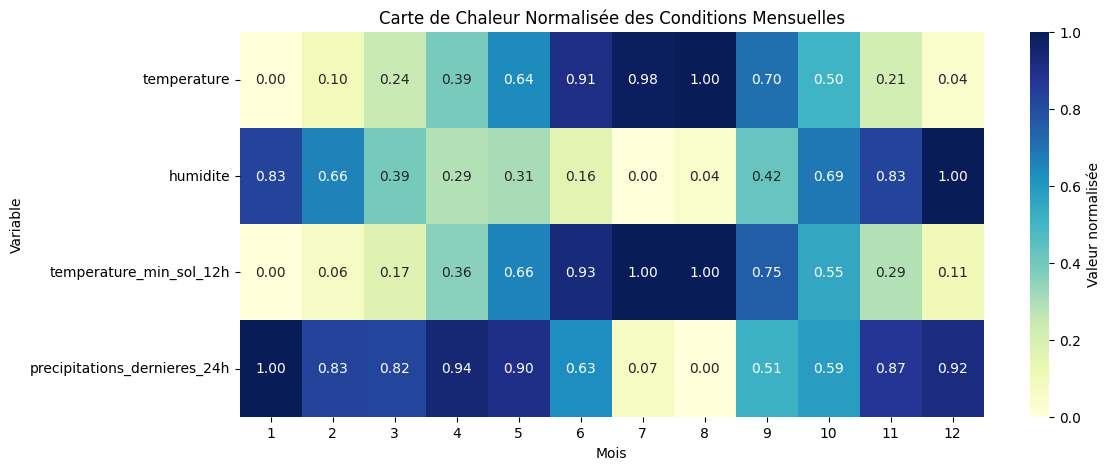

In [ ]:
# On regroupe par mois
releve['date'] = pd.to_datetime(releve['date'])
releve['mois'] = releve['date'].dt.month

variables = [
    'temperature',
    'humidite',
    'temperature_min_sol_12h',
    'precipitations_dernieres_24h' ]


moy_mois = releve.groupby('mois')[variables].mean().T

# Normalisation des variables
norm_mois = moy_mois.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=1)

plt.figure(figsize=(12,5))
sns.heatmap(norm_mois, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'Valeur normalisée'})
plt.title("Carte de chaleur normalisée des conditions météorologiques mensuelles")
plt.xlabel("Mois")
plt.ylabel("Variable")
plt.show()

## Les différentes températures pour chaque culture (I)

In [1]:
culture = pd.read_sql("SELECT * FROM culture", bdd)

contrainte = pd.read_sql("SELECT * FROM contrainte_temperature", bdd)

culture = culture.merge(contrainte, on='id_culture')

culture.head()

variables = [
    't_min_germination',
    't_opt_germination',
    't_ideale_croissance',
    't_min_croissance'
]


plt.figure(figsize=(16,6))

for var in variables:
    sns.scatterplot(
        data=culture,
        x='nom_culture',
        y=var,
        alpha=0.6
    )

plt.xticks(rotation=60, fontsize=5)
plt.title("Cultures")
plt.ylabel("Valeur")
plt.xlabel("Nom de la culture")
plt.tight_layout()
plt.show()

NameError: name 'pd' is not defined

## Température mensuelle par rapport aux températures idéales des plantes (I)

In [ ]:
from matplotlib.lines import Line2D


# Conversion de la température en Celsius arrondi
releve['temperature'] = releve['temperature'] - 273.15
releve['temperature'] = releve['temperature'].round(1)

releve['date'] = pd.to_datetime(releve['date'])
releve['mois'] = releve['date'].dt.month

moy_mois = releve.groupby('mois')['temperature'].mean()


culture_vars = [
    't_min_germination',
    't_opt_germination',
    't_ideale_croissance',
    't_min_croissance'
]


# Min and max pour chaque variable
min_vals = culture[culture_vars].min()
max_vals = culture[culture_vars].max()


plt.figure(figsize=(10,6))

# Température de l'environnement
sns.lineplot(data=plot_tmp, x='mois', y='temperature_env', marker='o', label="température d'environnement")

colors = ['blue','green','orange','red']
legend_elements = [
    Line2D([0], [0], color='black', marker='o', label='Température environnement') ]



for var, color in zip(culture_vars, colors):

    plt.plot(
        plot_tmp['mois'],
        [min_vals[var]] * 12,
        linestyle='--',
        color=color
    )

    plt.plot(
        plot_tmp['mois'],
        [max_vals[var]] * 12,
        linestyle='-',
        color=color
    )

    legend_elements.append(
        Line2D([0], [0], color=color, linestyle='--',
               label=f"{var} (min)")
    )
    legend_elements.append(
        Line2D([0], [0], color=color, linestyle='-',
               label=f"{var} (max)")
    )

plt.title("Température mensuelle par rapport aux températures idéales des plantes")
plt.xlabel("Mois")
plt.ylabel("Température (°C)")
plt.xticks(range(1,13))
plt.legend(handles=legend_elements,
           bbox_to_anchor=(1.02,1),
           loc='upper left',
           title="Variables")

plt.grid(True)
plt.tight_layout()
plt.show()